# Does Winning the Toss Actually Matter in the IPL,  and Does It Depend on the Venue?

**Dataset:** ball-by-ball IPL data, 2008-2026 seasons (Cricsheet, via Kaggle),  ~283,000 deliveries across 1,193 matches.

**Business question:** Toss decisions are treated as a big strategic moment in T20 cricket,  captains study pitch reports, dew forecasts, and historical venue trends before deciding whether to bat or field. This notebook asks a simple, checkable version of that belief: **does winning the toss actually correlate with winning the match, overall and at specific venues,  or is a lot of the "toss chatter" just narrative on top of noise?**

**Approach:** aggregate ball-by-ball deliveries to match level, test the overall toss→win relationship, break it down by venue with proper uncertainty bounds (not just raw percentages), and stress-test any venue-level "finding" against the number of comparisons being made.


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportion_confint
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'figure.facecolor': 'white'
})
pd.set_option('display.max_columns', None)

df = pd.read_csv('IPL.csv', low_memory=False)
print(f"{df.shape[0]:,} deliveries across {df['match_id'].nunique()} matches, "
      f"{df['season'].nunique()} seasons ({df['season'].min()}–{df['season'].max()})")


283,678 deliveries across 1193 matches, 19 seasons (2007/08–2026)


## 1. Cleaning: venue names are not unique identifiers

The raw `venue` field has **59 distinct strings** for what is really a much smaller number of physical grounds,  the same stadium is logged differently across seasons (`"Eden Gardens"` vs `"Eden Gardens, Kolkata"`), and a few grounds were renamed mid-dataset (Feroz Shah Kotla → Arun Jaitley Stadium; Sardar Patel Stadium, Motera → Narendra Modi Stadium). Without fixing this, any venue-level analysis silently splits each ground's sample size and weakens every test below.

A manual canonical mapping (built by inspecting all 59 raw values) collapses this to the actual number of grounds used.

In [2]:
VENUE_MAP = {
    'Arun Jaitley Stadium': 'Arun Jaitley Stadium (Delhi)',
    'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium (Delhi)',
    'Feroz Shah Kotla': 'Arun Jaitley Stadium (Delhi)',
    'Barabati Stadium': 'Barabati Stadium (Cuttack)',
    'Barsapara Cricket Stadium, Guwahati': 'Barsapara Cricket Stadium (Guwahati)',
    'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow': 'Ekana Cricket Stadium (Lucknow)',
    'Brabourne Stadium': 'Brabourne Stadium (Mumbai)',
    'Brabourne Stadium, Mumbai': 'Brabourne Stadium (Mumbai)',
    'Buffalo Park': 'Buffalo Park (SA)',
    'De Beers Diamond Oval': 'De Beers Diamond Oval (SA)',
    'Dr DY Patil Sports Academy': 'Dr DY Patil Sports Academy (Mumbai)',
    'Dr DY Patil Sports Academy, Mumbai': 'Dr DY Patil Sports Academy (Mumbai)',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium': 'ACA-VDCA Stadium (Visakhapatnam)',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam': 'ACA-VDCA Stadium (Visakhapatnam)',
    'Dubai International Cricket Stadium': 'Dubai International Stadium (UAE)',
    'Eden Gardens': 'Eden Gardens (Kolkata)',
    'Eden Gardens, Kolkata': 'Eden Gardens (Kolkata)',
    'Green Park': 'Green Park (Kanpur)',
    'Himachal Pradesh Cricket Association Stadium': 'HPCA Stadium (Dharamsala)',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala': 'HPCA Stadium (Dharamsala)',
    'Holkar Cricket Stadium': 'Holkar Cricket Stadium (Indore)',
    'JSCA International Stadium Complex': 'JSCA International Stadium (Ranchi)',
    'Kingsmead': 'Kingsmead (SA)',
    'M Chinnaswamy Stadium': 'M Chinnaswamy Stadium (Bengaluru)',
    'M Chinnaswamy Stadium, Bengaluru': 'M Chinnaswamy Stadium (Bengaluru)',
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium (Bengaluru)',
    'MA Chidambaram Stadium': 'MA Chidambaram Stadium (Chennai)',
    'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium (Chennai)',
    'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium (Chennai)',
    'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur': 'Maharaja Yadavindra Singh Stadium (Mullanpur)',
    'Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh': 'Maharaja Yadavindra Singh Stadium (Mullanpur)',
    'Maharashtra Cricket Association Stadium': 'MCA Stadium (Pune)',
    'Maharashtra Cricket Association Stadium, Pune': 'MCA Stadium (Pune)',
    'Narendra Modi Stadium, Ahmedabad': 'Narendra Modi Stadium (Ahmedabad)',
    'Sardar Patel Stadium, Motera': 'Narendra Modi Stadium (Ahmedabad)',
    'Nehru Stadium': 'Nehru Stadium (Kochi)',
    'New Wanderers Stadium': 'Wanderers Stadium (SA)',
    'Newlands': 'Newlands (SA)',
    'OUTsurance Oval': 'OUTsurance Oval (SA)',
    'Punjab Cricket Association IS Bindra Stadium': 'PCA Stadium (Mohali)',
    'Punjab Cricket Association IS Bindra Stadium, Mohali': 'PCA Stadium (Mohali)',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh': 'PCA Stadium (Mohali)',
    'Punjab Cricket Association Stadium, Mohali': 'PCA Stadium (Mohali)',
    'Rajiv Gandhi International Stadium': 'Rajiv Gandhi Intl Stadium (Hyderabad)',
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi Intl Stadium (Hyderabad)',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad': 'Rajiv Gandhi Intl Stadium (Hyderabad)',
    'Saurashtra Cricket Association Stadium': 'Saurashtra Cricket Assoc Stadium (Rajkot)',
    'Sawai Mansingh Stadium': 'Sawai Mansingh Stadium (Jaipur)',
    'Sawai Mansingh Stadium, Jaipur': 'Sawai Mansingh Stadium (Jaipur)',
    'Shaheed Veer Narayan Singh International Stadium': 'Shaheed Veer Narayan Singh Stadium (Raipur)',
    'Sharjah Cricket Stadium': 'Sharjah Cricket Stadium (UAE)',
    'Sheikh Zayed Stadium': 'Zayed Cricket Stadium (Abu Dhabi)',
    'Zayed Cricket Stadium, Abu Dhabi': 'Zayed Cricket Stadium (Abu Dhabi)',
    "St George's Park": "St George's Park (SA)",
    'Subrata Roy Sahara Stadium': 'MCA Stadium (Pune)',
    'SuperSport Park': 'SuperSport Park (SA)',
    'Vidarbha Cricket Association Stadium, Jamtha': 'VCA Stadium (Nagpur)',
    'Wankhede Stadium': 'Wankhede Stadium (Mumbai)',
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium (Mumbai)',
}
NEUTRAL_KEYWORDS = ['(SA)', '(UAE)', 'Abu Dhabi']

df['venue_clean'] = df['venue'].map(VENUE_MAP).fillna(df['venue'])
df['is_neutral'] = df['venue_clean'].apply(lambda v: any(k in v for k in NEUTRAL_KEYWORDS))

print(f"Raw venue strings: {df['venue'].nunique()}  ->  Canonical grounds: {df['venue_clean'].nunique()}")
print(f"Of which neutral-country venues (South Africa 2009, UAE 2014/2020/21): "
      f"{df.loc[df['is_neutral'],'venue_clean'].nunique()}")


Raw venue strings: 59  ->  Canonical grounds: 36
Of which neutral-country venues (South Africa 2009, UAE 2014/2020/21): 11


## 2. Building a match-level table from ball-by-ball data

The raw data is one row per delivery. Everything below needs one row per **match**,  venue, toss decision, final score per innings, and who actually won. Ties decided by a super over are resolved to the super-over winner; matches that were abandoned with **no result** (9 of 1,193,  about 0.75%) are dropped, since there's no winner to attach a toss effect to.

In [3]:
meta = df.drop_duplicates('match_id')[
    ['match_id','venue_clean','city','date','season','toss_winner','toss_decision',
     'match_won_by','win_outcome','result_type','superover_winner','is_neutral']
].set_index('match_id')

innings_scores = (df[df['innings'].isin([1,2])]
                  .groupby(['match_id','innings'])
                  .agg(runs=('team_runs','max'), wkts=('team_wicket','max'), team=('batting_team','first'))
                  .reset_index())

inn1 = innings_scores[innings_scores['innings']==1].set_index('match_id')[['team','runs','wkts']]
inn1.columns = ['bat1_team','bat1_runs','bat1_wkts']
inn2 = innings_scores[innings_scores['innings']==2].set_index('match_id')[['team','runs','wkts']]
inn2.columns = ['bat2_team','bat2_runs','bat2_wkts']

matches = meta.join(inn1).join(inn2)

# ties are recorded with match_won_by == 'Unknown' but resolved via a super over -> use that instead
matches['winner'] = np.where(matches['match_won_by'] != 'Unknown', matches['match_won_by'], matches['superover_winner'])
n_before = len(matches)
matches = matches[matches['winner'].notna() & (matches['winner'] != 'Unknown')].copy()
print(f"Dropped {n_before - len(matches)} no-result matches with no winner. {len(matches)} matches remain.")

matches['batting_first_won'] = matches['winner'] == matches['bat1_team']
matches['toss_winner_won']   = matches['winner'] == matches['toss_winner']
matches['season_year'] = matches['season'].str[:4].astype(int)
matches.head(3)


Dropped 9 no-result matches with no winner. 1184 matches remain.


,venue_clean,city,date,season,toss_winner,toss_decision,match_won_by,win_outcome,result_type,superover_winner,is_neutral,bat1_team,bat1_runs,bat1_wkts,bat2_team,bat2_runs,bat2_wkts,winner,batting_first_won,toss_winner_won,season_year
match_id,,,,,,,,,,,,,,,,,,,,,
335982,M Chinnaswamy Stadium (Bengaluru),Bangalore,2008-04-18,2007/08,Royal Challengers Bangalore,field,Kolkata Knight Riders,140 runs,NaN,NaN,False,Kolkata Knight Riders,222,3,Royal Challengers Bangalore,82.0,10.0,Kolkata Knight Riders,True,False,2007
335983,PCA Stadium (Mohali),Chandigarh,2008-04-19,2007/08,Chennai Super Kings,bat,Chennai Super Kings,33 runs,NaN,NaN,False,Chennai Super Kings,240,5,Kings XI Punjab,207.0,4.0,Chennai Super Kings,True,True,2007
335984,Arun Jaitley Stadium (Delhi),Delhi,2008-04-19,2007/08,Rajasthan Royals,bat,Delhi Daredevils,9 wickets,NaN,NaN,False,Rajasthan Royals,129,8,Delhi Daredevils,132.0,1.0,Delhi Daredevils,False,False,2007


## 3. The headline number: does winning the toss predict winning the match?

In [4]:
n = len(matches)
k = int(matches['toss_winner_won'].sum())
p = stats.binomtest(k, n, p=0.5).pvalue

print(f"Toss winner also won the match: {k}/{n} = {k/n:.1%}")
print(f"Two-sided binomial test vs. a 50% coin-flip baseline: p = {p:.3f}")


Toss winner also won the match: 612/1184 = 51.7%
Two-sided binomial test vs. a 50% coin-flip baseline: p = 0.257


**Reading this:** toss winners won 51.7% of matches,  barely above a coin flip, and the p-value (0.257) means we can't distinguish this from pure chance. **On its own, winning the toss tells you almost nothing about who wins the match.** That's the honest headline,  the more interesting question is whether the *decision* the toss winner makes matters, and whether either of those varies meaningfully by venue.

## 4. Does the *decision* matter more than the toss itself?

The toss only sets up a choice: bat first, or field first (bowl, chase the target later). This is where T20 strategy conversations actually focus,  so it's worth separating 'won the toss' from 'chose to field'.

In [5]:
decision_counts = matches['toss_decision'].value_counts()
by_decision = matches.groupby('toss_decision')['toss_winner_won'].agg(win_rate='mean', n='size')

overall_bat_first = matches['batting_first_won'].mean()
p_batfirst = stats.binomtest(int(matches['batting_first_won'].sum()), len(matches), p=0.5).pvalue

print("Toss decisions made:\n", decision_counts, "\n")
print("Toss-winner win rate, split by their decision:\n", by_decision.round(3), "\n")
print(f"Batting first wins the match {overall_bat_first:.1%} of the time overall (binomial p={p_batfirst:.4f})")


Toss decisions made:
 toss_decision
field    781
bat      403
Name: count, dtype: int64 

Toss-winner win rate, split by their decision:
                win_rate    n
toss_decision               
bat               0.464  403
field             0.544  781 

Batting first wins the match 45.9% of the time overall (binomial p=0.0048)


**This is the real signal.** Batting first wins only ~46% of matches league-wide,  a gap from 50% that *is* statistically significant (p = 0.005),  and it lines up with what teams are actually doing: the share of toss winners choosing to field has climbed from about 55% in the first season to 96% in 2026. Captains have converged on "field first," and the data broadly supports that instinct at the league level, even though winning the toss itself barely matters,  what matters is what you do with it.

## 5. Has this shifted over time?

Linear trend in batting-first win rate across seasons: slope=+0.0007/yr, r=0.063, p=0.799


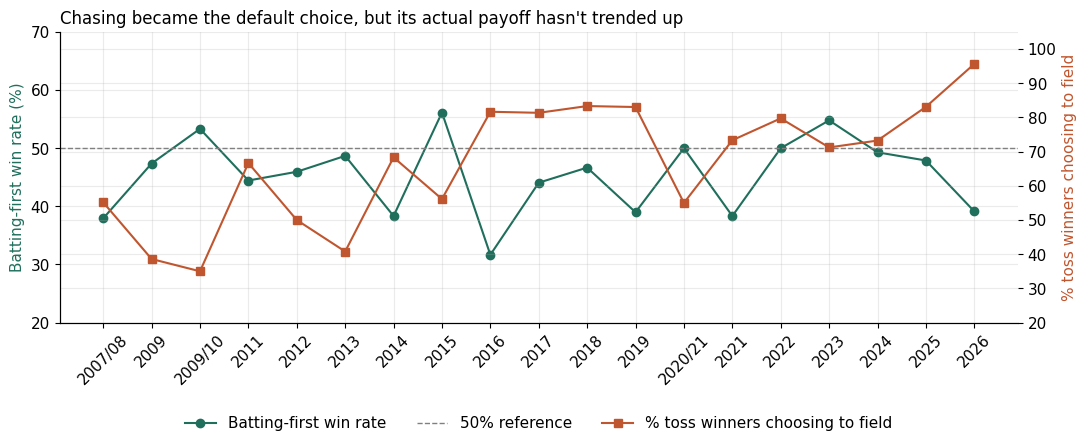

In [6]:
season = matches.groupby('season').agg(
    n=('winner','size'), bat_first_win_rate=('batting_first_won','mean'),
    pct_chose_field=('toss_decision', lambda x: (x=='field').mean()),
    season_year=('season_year','first')
).sort_values('season_year')

slope, intercept, r, p_trend, se = stats.linregress(season['season_year'], season['bat_first_win_rate'])
print(f"Linear trend in batting-first win rate across seasons: slope={slope:+.4f}/yr, r={r:.3f}, p={p_trend:.3f}")

fig, ax1 = plt.subplots(figsize=(11,5))
ax1.plot(season.index, season['bat_first_win_rate']*100, marker='o', color='#1f6f5c', label='Batting-first win rate')
ax1.axhline(50, ls='--', color='gray', lw=1, label='50% reference')
ax1.set_ylabel('Batting-first win rate (%)', color='#1f6f5c'); ax1.tick_params(axis='x', rotation=45); ax1.set_ylim(20,70)
ax2 = ax1.twinx()
ax2.plot(season.index, season['pct_chose_field']*100, marker='s', color='#c0562f', label='% toss winners choosing to field')
ax2.set_ylabel('% toss winners choosing to field', color='#c0562f'); ax2.set_ylim(20,105)
lines1, labels1 = ax1.get_legend_handles_labels(); lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='lower center', bbox_to_anchor=(0.5,-0.42), ncol=3, frameon=False)
plt.title("Chasing became the default choice, but its actual payoff hasn't trended up", fontsize=12, loc='left')
plt.tight_layout(); plt.show()


**Reading this:** the choice to field first has trended steadily toward near-universal (rule changes like the 2023 Impact Player rule, better dew forecasting, and flatter used pitches all plausibly contribute),  but the actual win-rate payoff of batting first bounces around noisily season to season with **no significant trend** (r = 0.06, p = 0.80). Teams have converged on a strategy whose real-world edge hasn't obviously gotten bigger over time. That gap,  between "what everyone does" and "how much it actually helps",  is worth a sentence in any memo about this.

## 6. The headline comparison: does this vary by venue?

Restricting to home (non-neutral) venues with at least 15 matches recorded, so single-digit sample sizes don't produce misleadingly extreme percentages.

In [7]:
def venue_toss_stats(sub, min_n=15):
    g = sub.groupby('venue_clean').agg(n=('winner','size'), toss_wins=('toss_winner_won','sum'))
    g = g[g['n'] >= min_n].copy()
    g['toss_win_rate'] = g['toss_wins'] / g['n']
    ci_lo, ci_hi, pvals = [], [], []
    for _, r in g.iterrows():
        lo, hi = proportion_confint(r['toss_wins'], r['n'], method='wilson')
        pv = stats.binomtest(int(r['toss_wins']), int(r['n']), p=0.5).pvalue
        ci_lo.append(lo); ci_hi.append(hi); pvals.append(pv)
    g['ci_lo'], g['ci_hi'], g['p_value'] = ci_lo, ci_hi, pvals
    g['significant_05'] = g['p_value'] < 0.05
    return g.sort_values('toss_win_rate')

toss_venue = venue_toss_stats(matches[~matches['is_neutral']])
toss_venue[['n','toss_win_rate','ci_lo','ci_hi','p_value','significant_05']].round(3).sort_values('toss_win_rate', ascending=False)


,n,toss_win_rate,ci_lo,ci_hi,p_value,significant_05
venue_clean,,,,,,
Ekana Cricket Stadium (Lucknow),23,0.696,0.491,0.844,0.093,False
Sawai Mansingh Stadium (Jaipur),64,0.562,0.441,0.677,0.382,False
MCA Stadium (Pune),51,0.549,0.414,0.677,0.576,False
M Chinnaswamy Stadium (Bengaluru),99,0.545,0.448,0.640,0.422,False
Dr DY Patil Sports Academy (Mumbai),37,0.541,0.384,0.690,0.743,False
Wankhede Stadium (Mumbai),128,0.531,0.445,0.616,0.536,False
ACA-VDCA Stadium (Visakhapatnam),17,0.529,0.310,0.738,1.000,False
Brabourne Stadium (Mumbai),27,0.519,0.340,0.693,1.000,False
Eden Gardens (Kolkata),101,0.515,0.419,0.610,0.842,False


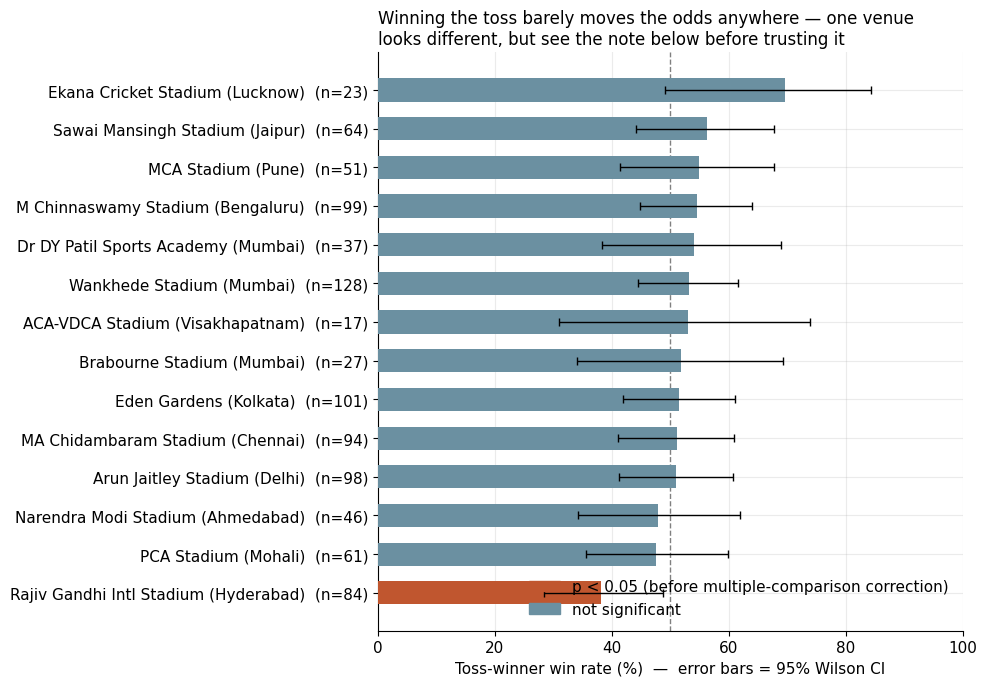

In [8]:
fig, ax = plt.subplots(figsize=(10,7))
y = np.arange(len(toss_venue))
colors = ['#c0562f' if s else '#6b90a1' for s in toss_venue['significant_05']]
ax.barh(y, toss_venue['toss_win_rate']*100, color=colors, height=0.6, zorder=3)
ax.errorbar(toss_venue['toss_win_rate']*100, y,
            xerr=[(toss_venue['toss_win_rate']-toss_venue['ci_lo'])*100, (toss_venue['ci_hi']-toss_venue['toss_win_rate'])*100],
            fmt='none', ecolor='black', elinewidth=1, capsize=3, zorder=4)
ax.axvline(50, color='gray', ls='--', lw=1, zorder=2)
ax.set_yticks(y); ax.set_yticklabels([f"{v}  (n={n})" for v, n in zip(toss_venue.index, toss_venue['n'])])
ax.set_xlabel('Toss-winner win rate (%)  —  error bars = 95% Wilson CI'); ax.set_xlim(0,100)
ax.set_title("Winning the toss barely moves the odds anywhere — one venue\nlooks different, but see the note below before trusting it", loc='left', fontsize=12)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#c0562f', label='p < 0.05 (before multiple-comparison correction)'),
                    Patch(color='#6b90a1', label='not significant')], loc='lower right', frameon=False)
plt.tight_layout(); plt.show()


## 7. The honesty check: is that one "significant" venue real, or expected noise?

Rajiv Gandhi Intl Stadium (Hyderabad) comes out significant at p = 0.038,  toss winners there have actually won *less* often (38%). Before writing that into a recommendation, it needs a sanity check: **we just ran 14 independent significance tests.** At a 5% threshold, chance alone predicts roughly 0.7 false positives across 14 venues,  finding exactly one "significant" result is close to what you'd expect if there were *no* real venue effect at all.

In [9]:
contingency = np.array([toss_venue['toss_wins'], toss_venue['n'] - toss_venue['toss_wins']])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square test across all {len(toss_venue)} venues at once: chi2={chi2:.2f}, dof={dof}, p={p_chi:.4f}")
print("-> Overall, venue does NOT explain a significant amount of variation in toss-winner win rate.")
print("   The single p<0.05 venue is best treated as noise, not a venue-specific effect, without more seasons of data.")


Chi-square test across all 14 venues at once: chi2=11.12, dof=13, p=0.6008
-> Overall, venue does NOT explain a significant amount of variation in toss-winner win rate.
   The single p<0.05 venue is best treated as noise, not a venue-specific effect, without more seasons of data.


## 8. Does the toss winner win *big* where the "advantage" looks strongest?

If a venue's toss edge were real, it should also show up in bigger winning margins there, not just a marginally higher win rate. Margins aren't directly comparable across chase wins (measured in wickets) and defended-total wins (measured in runs), so each is checked against venue toss-win-rate separately.

In [10]:
import re
def parse_margin(s):
    if pd.isna(s): return (np.nan, np.nan)
    m = re.match(r'(\d+)\s+(runs|wickets)', str(s))
    return (int(m.group(1)), m.group(2)) if m else (np.nan, np.nan)

matches[['margin_value','margin_type']] = matches['win_outcome'].apply(lambda s: pd.Series(parse_margin(s)))

merged = matches[~matches['is_neutral']].merge(toss_venue[['toss_win_rate']], left_on='venue_clean', right_index=True)
toss_winner_won = merged[merged['toss_winner_won']]

for mtype in ['runs','wickets']:
    sub = toss_winner_won[toss_winner_won['margin_type']==mtype]
    corr = sub[['toss_win_rate','margin_value']].corr().iloc[0,1]
    print(f"{mtype:8s}: mean margin {sub['margin_value'].mean():.1f}, "
          f"correlation with venue toss-win-rate = {corr:+.3f}  (n={len(sub)})")


runs    : mean margin 28.9, correlation with venue toss-win-rate = +0.129  (n=140)
wickets : mean margin 6.1, correlation with venue toss-win-rate = -0.055  (n=333)


**No signal here either**,  margin size is essentially uncorrelated with how "toss-favoring" a venue looks (both correlations are near zero). That's consistent with Section 7: there isn't a robust venue-level toss effect hiding in this dataset once you look for it two different ways.

## 9. Data limitation worth stating explicitly

Dew is the most commonly cited reason chasing is easier in T20,  the ball gets harder to grip for bowlers under dew in the second innings, typically in night matches. **This dataset has no day/night or match-start-time field**, so the day/night → dew → chase-advantage chain can't be tested directly here; it can only be inferred indirectly (e.g., via known venue/climate priors), which isn't rigorous enough to report as a finding. Flagging what the data can't answer is as important as reporting what it can.

## 10. Summary,  the memo version

| Question | Finding | Confidence |
|---|---|---|
| Does winning the toss predict winning the match? | No,  51.7%, statistically indistinguishable from 50% | High (n=1,184) |
| Does batting first vs. fielding first matter? | Yes,  batting first wins only ~46% league-wide | High, p=0.005 |
| Has the "field-first" trend paid off more over time? | No significant trend in the actual payoff, despite near-universal adoption | Moderate |
| Does the venue matter? | One venue (Hyderabad) looks different, but a league-wide test across all venues found no significant venue effect overall | Low,  treat as noise pending more seasons |
| Do winning margins confirm any venue effect? | No,  margin size doesn't correlate with venue toss-win-rate | Low signal |
| Is dew/day-night driving any of this? | Can't test directly,  data doesn't record match start time | Data gap, not a finding |

**Bottom line for a decision-maker:** don't over-invest in venue-specific toss strategy from this dataset alone,  the one robust, defensible finding is the league-wide chasing advantage, not a per-venue playbook. That's a more useful (and more honest) takeaway than a colorful heatmap implying every ground has its own "secret" toss trend.
